Advanced Model

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import ( AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer)
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5628.17it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.424807,0.337715,0.848400,0.799365,0.881237,0.731412
2,0.317239,0.345422,0.849500,0.813020,0.834694,0.792444
3,0.254911,0.372028,0.857800,0.821581,0.852382,0.792928


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Test Accuracy: 0.8503
Test Precision: 0.8772
Test Recall: 0.7370
Test F1 Score: 0.8010


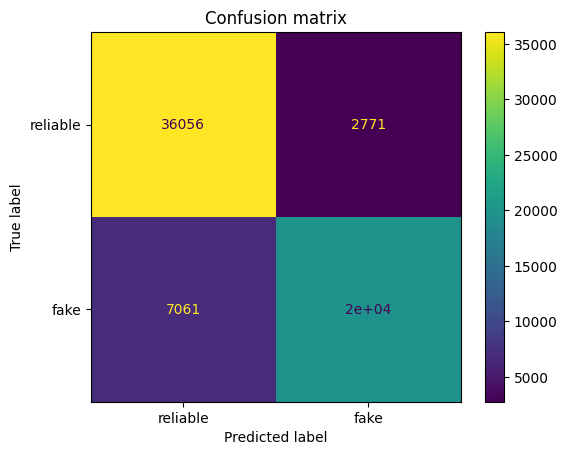

In [2]:
train_df = pd.read_csv('dataset/splits_sample/train.csv')
val_df = pd.read_csv('dataset/splits_sample/val.csv')
test_df = pd.read_csv('dataset/splits_sample/test.csv')

train_df = train_df.sample(n=10000, random_state=42).reset_index(drop=True)
val_df = val_df.sample(n=10000, random_state=42).reset_index(drop=True)

FAKE_LABELS = {'fake', 'consipracy', 'junksci', 'hate', 'unreliable', 'bias'}

def binarize(label):
    return 1 if str(label).strip().lower() in FAKE_LABELS else 0

train_df['label'] = train_df['type'].apply(binarize)
val_df['label'] = val_df['type'].apply(binarize)
test_df['label'] = test_df['type'].apply(binarize)

tokenizer = AutoTokenizer.from_pretrained('roberta-base')

def tokenize_fn(batch):
    return tokenizer(
        batch['content_clean_stem'],
        truncation=True,
        padding='max_length',
        max_length=128,
    )
    
train_ds = Dataset.from_pandas(train_df[['content_clean_stem', 'label']])
val_ds = Dataset.from_pandas(val_df[['content_clean_stem', 'label']])
test_ds = Dataset.from_pandas(test_df[['content_clean_stem', 'label']])

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precission, recall, f1, _ = precision_recall_fscore_support(
                                                                labels,
                                                                preds,
                                                                average='binary',
                                                                )
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precission, 'recall': recall}

args = TrainingArguments(
    output_dir='./results',
    fp16=True,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

# test_results = trainer.evaluate(test_ds)
# print("Test results", test_results)

test_preds = trainer.predict(test_ds)
test_y_pred = np.argmax(test_preds.predictions, axis=-1)
test_y_true = test_preds.label_ids

precission, recall, f1, _ = precision_recall_fscore_support(
                                                            test_y_true,
                                                            test_y_pred,
                                                            average='binary',
                                                            )
acc = accuracy_score(test_y_true, test_y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {precission:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

cm_test = confusion_matrix(test_y_true, test_y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=['reliable', 'fake']
)

disp.plot()
plt.title('Confusion matrix')
plt.show()

    